# Bounding box detection - Racoon data


## Data files
- images_racoon.rar: contain images of racoons
- train_labels.cv: contains coordinates for bounding box for every image

### Import the necessary libraries

In [0]:
from matplotlib import pyplot as plt
import cv2
import numpy as np
import pandas as pd

In [0]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

### Change directory

In [3]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


### Load the training data from train.csv file

In [4]:
train_df = pd.read_csv('/content/drive/My Drive/AIML/Residency 9/train_labels.csv')
train_df.head()

,filename,width,height,class,xmin,ymin,xmax,ymax
0,raccoon-17.jpg,259,194,raccoon,95,60,167,118
1,raccoon-11.jpg,660,432,raccoon,3,1,461,431
2,raccoon-63.jpg,600,400,raccoon,74,107,280,290
3,raccoon-63.jpg,600,400,raccoon,227,93,403,298
4,raccoon-60.jpg,273,185,raccoon,58,33,197,127


In [5]:
train_df['class'].value_counts()

raccoon    173
Name: class, dtype: int64

In [0]:
img_path = '/content/drive/My Drive/AIML/Residency 9/images_racoon/images/images/'

In [7]:
train_df['image_file'] = img_path + train_df['filename']
train_df.head()

,filename,width,height,class,xmin,ymin,xmax,ymax,image_file
0,raccoon-17.jpg,259,194,raccoon,95,60,167,118,/content/drive/My Drive/AIML/Residency 9/image...
1,raccoon-11.jpg,660,432,raccoon,3,1,461,431,/content/drive/My Drive/AIML/Residency 9/image...
2,raccoon-63.jpg,600,400,raccoon,74,107,280,290,/content/drive/My Drive/AIML/Residency 9/image...
3,raccoon-63.jpg,600,400,raccoon,227,93,403,298,/content/drive/My Drive/AIML/Residency 9/image...
4,raccoon-60.jpg,273,185,raccoon,58,33,197,127,/content/drive/My Drive/AIML/Residency 9/image...


In [8]:
train_df['image_file'][0]

'/content/drive/My Drive/AIML/Residency 9/images_racoon/images/images/raccoon-17.jpg'

### Print the shape of the train dataset

In [9]:
train_df.shape

(173, 9)

In [10]:
train_df.dtypes

filename      object
width          int64
height         int64
class         object
xmin           int64
ymin           int64
xmax           int64
ymax           int64
image_file    object
dtype: object

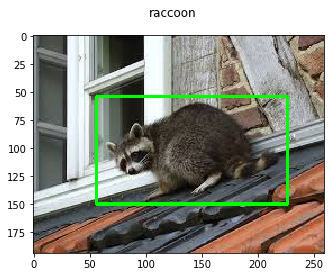

In [11]:
#Pickup a random image number
img_num = np.random.randint(0, train_df.shape[0])

#Read the image and draw a rectangle as per bounding box information
img = cv2.imread(train_df.loc[img_num,'image_file'])
cv2.rectangle(img, 
             (train_df.loc[img_num, 'xmin'],train_df.loc[img_num, 'ymin']),
             (train_df.loc[img_num, 'xmax'],train_df.loc[img_num, 'ymax']), 
             (0,255,0),
             2)
#Convert BGR format (used by opencv to RGB format used by matplotlib)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

#Draw image using matplotlib
plt.suptitle(train_df.loc[img_num, 'class'])
plt.imshow(img)
plt.show()

### Declare a variable IMAGE_SIZE = 128 as we will be using MobileNet which will be taking Input shape as 128 * 128 

In [0]:
IMAGE_SIZE = 128

### With the help of csv.reader write a for loop which can load the train.csv file and store the path, width, height, x0,y0,x1,y1 in induvidual variables. <br>
1. Create a list variable known as 'path' which has all the path for all the training images
2. Create an array 'coords' which has the resized coordinates of the bounding box for the training images

<u>Note:</u> All the training images should be downsampled to 128 * 128 as it is the input shape of MobileNet (which we will be using for Object detection). Hence the corresponding coordinates of the bounding boxes should be changed to match the image dimension of 128 * 128 

In [13]:
import tensorflow as tf

In [0]:
import csv

#list of image paths
path = []

#Regression labels - 4 numbers per example image
coords = []

with open('/content/drive/My Drive/AIML/Residency 9/train_labels.csv') as f:
  data = csv.reader(f)
  next(data)
  for row in data:
    path.append(row[0])

    
    #Read and resize bounding box co-ordinates
    img_width  = int(row[1]) #width
    img_height = int(row[2]) #height

    xmin = int(row[4]) * IMAGE_SIZE/img_width #xmin
    xmax = int(row[6]) * IMAGE_SIZE/img_width #xmax

    ymin = int(row[5]) * IMAGE_SIZE/img_height #ymin
    ymax = int(row[7]) * IMAGE_SIZE/img_height #ymax

    #We will ask model to predict xmin, ymin, width and height of bounding box
    coords.append([xmin, ymin, xmax-xmin, ymax-ymin])


    #Make bounding boxes (x, y, w, h) as numbers between 0 and 1 - this seems to work better
    #coords.append(coords/IMAGE_SIZE)

f.close()       

In [15]:
len(path)

173

In [16]:
len(coords)

173

In [17]:
train_df.shape[0]

173

In [18]:
path[172]

'raccoon-152.jpg'

### Write a for loop which can load all the training images into a variable 'batch_images' using the paths from the 'paths' variable
<u>Note:</u> Convert the image to RGB scale as the MobileNet accepts 3 channels as inputs   

In [0]:
image_depth = 3

In [0]:
import cv2

#Create empty arrays
#1. To hold image input
batch_images = np.zeros(shape=(train_df.shape[0],IMAGE_SIZE, IMAGE_SIZE, 3))

#print(batch_images.shape)
#batch_images = []

for i in range(len(path)):

    #Read image and resize
    img = tf.keras.preprocessing.image.load_img(img_path + path[i], 
                                                target_size=(IMAGE_SIZE,IMAGE_SIZE,image_depth))
    

    #input_img_resize=cv2.resize(img,(128,128))

    #Conver to numpy array
    img_array = tf.keras.preprocessing.image.img_to_array(img)

    #input_img_resize=cv2.resize(img_array,(128,128))

    img_array = np.expand_dims(img_array,axis=0)
    #print(img_array.shape)

    batch_images[i] = img_array



In [41]:
batch_images.shape

(173, 128, 128, 3)

In [0]:
#Normalize batch images as per Pre-trained model to be used
batch_images = tf.keras.applications.mobilenet.preprocess_input(batch_images)

### Import MobileNet and load MobileNet into a variable named 'model' which takes input shape of 128 * 128 * 3. Freeze all the layers. Add convolution and reshape layers at the end to ensure the output is 4 coordinates

In [0]:
model = tf.keras.applications.mobilenet.MobileNet(include_top=False, #Do not include FC layer at the end
                                                  input_shape=(IMAGE_SIZE,IMAGE_SIZE, image_depth),
                                                  weights='imagenet')

In [0]:
#Set pre-trained model layers to not trainable
for layer in model.layers:
    layer.trainable = False

In [0]:
#get Output layer of Pre0trained model
x = model.output

#x = tf.keras.layers.GlobalAveragePooling2D()(x)

#Flatten the output to feed to Dense layer

#Add Dropout
x = tf.keras.layers.Dropout(0.5)(x)


#Batch Norm
x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.Flatten()(x)

#Regression
bbox_output = tf.keras.layers.Dense(4 , activation='sigmoid')(x)

In [0]:
#Using Keras Model class
final_model = tf.keras.models.Model(inputs=model.input, #Pre-trained model input as input layer
                                    outputs=bbox_output) #Output layer added

In [47]:
final_model.summary()

Model: "model_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_2 (InputLayer)         [(None, 128, 128, 3)]     0         
_________________________________________________________________
conv1_pad (ZeroPadding2D)    (None, 129, 129, 3)       0         
_________________________________________________________________
conv1 (Conv2D)               (None, 64, 64, 32)        864       
_________________________________________________________________
conv1_bn (BatchNormalization (None, 64, 64, 32)        128       
_________________________________________________________________
conv1_relu (ReLU)            (None, 64, 64, 32)        0         
_________________________________________________________________
conv_dw_1 (DepthwiseConv2D)  (None, 64, 64, 32)        288       
_________________________________________________________________
conv_dw_1_bn (BatchNormaliza (None, 64, 64, 32)        128 

### Define a custom loss function IoU which calculates Intersection Over Union

In [0]:
def loss(gt,pred):
    intersections = 0
    unions = 0
    diff_width = np.minimum(gt[:,0] + gt[:,2], pred[:,0] + pred[:,2]) - np.maximum(gt[:,0], pred[:,0])
    diff_height = np.minimum(gt[:,1] + gt[:,3], pred[:,1] + pred[:,3]) - np.maximum(gt[:,1], pred[:,1])
    intersection = diff_width * diff_height
    
    # Compute union
    area_gt = gt[:,2] * gt[:,3]
    area_pred = pred[:,2] * pred[:,3]
    union = area_gt + area_pred - intersection

#     Compute intersection and union over multiple boxes
    for j, _ in enumerate(union):
        if union[j] > 0 and intersection[j] > 0 and union[j] >= intersection[j]:
            intersections += intersection[j]
            unions += union[j]

    # Compute IOU. Use epsilon to prevent division by zero
    iou = np.round(intersections / (unions + epsilon()), 4)
    iou = iou.astype(np.float32)
    return iou

def IoU(y_true, y_pred):
    iou = tf.py_func(loss, [y_true, y_pred], tf.float32)
    return iou

### Write model.compile function & model.fit function with: <br>
1. Optimizer = Adam, Loss = 'mse' and metrics = IoU
2. Epochs = 30, batch_size = 32, verbose = 1

In [0]:
final_model.compile(optimizer='adam', loss='mse', metrics=[IoU])

In [50]:
final_model.fit(batch_images,bbox_output,
          epochs=30,
          batch_size = 32,
          steps_per_epoch = train_df.shape[0])

Train on 173 samples
Epoch 1/30


UnknownError: ignored

### Pick a test image from the given data

### Resize the image to 128 * 128 and preprocess the image for the MobileNet model

### Predict the coordinates of the bounding box for the given test image

In [0]:
final_model.predict()

### Plot the test image using .imshow and draw a boundary box around the image with the coordinates obtained from the model

In [0]:
x0 = int(region[0] * image_width / IMAGE_SIZE) # Scale the BBox
y0 = int(region[1] * image_height / IMAGE_SIZE)

x1 = int((region[2]) * image_width / IMAGE_SIZE)
y1 = int((region[3]) * image_height / IMAGE_SIZE)


import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np


# Create figure and axes
fig,ax = plt.subplots(1)

# Display the image
ax.imshow(unscaled)

# Create a Rectangle patch
rect = patches.Rectangle((x0, y0), (x1 - x0) , (y1 - y0) , linewidth=2, edgecolor='r', facecolor='none')

# Add the patch to the Axes
ax.add_patch(rect)

plt.show()